# 03 一次指数平滑模型（Simple Exponential Smoothing）

本 notebook 是**完全独立**的：数据、公式、计算、绘图代码都在这里，不需要任何外部 `.py` 文件，单独打开就能运行。

**评估方式——留出法**：把整段数据从「预测起始期」处切成两段，前段只用来建模，后段只用来检验。SSE / SE / Theil U 全部按留出段的「实际值 vs 预测值」计算。



## 0. 环境准备（中文字体）

In [1]:
# 中文字体设置：自动适配 Windows / macOS / Linux
import matplotlib
from matplotlib import font_manager

_CAND = ["Microsoft YaHei", "SimHei", "PingFang SC", "Heiti SC",
         "Noto Sans CJK SC", "Source Han Sans SC", "WenQuanYi Zen Hei",
         "Droid Sans Fallback", "Arial Unicode MS"]
_have = {f.name for f in font_manager.fontManager.ttflist}
_pick = [n for n in _CAND if n in _have]
# 注意：font.family 要传"列表"，matplotlib 才会逐字回退
# （拉丁字母用 DejaVu Sans，中文用上面挑到的字体）
matplotlib.rcParams["font.family"] = _pick + ["DejaVu Sans"]
matplotlib.rcParams["axes.unicode_minus"] = False
print("可用中文字体:", _pick if _pick else "未找到，图中中文可能显示为方框")

可用中文字体: ['Droid Sans Fallback']


## 1. 导入与公用函数

In [2]:
import math
from statistics import NormalDist
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110


def z_value(conf=0.95):
    # 正态分布双侧分位数，95% 对应 1.96
    return NormalDist().inv_cdf(1 - (1 - conf) / 2)


def evaluate(actual, forecast, y, t_index, k=0):
    # 在留出段上计算 SSE / MSE / RMSE / 残差标准误 SE / Theil U1 / U2
    # k = 该模型的待估参数个数（用于 SE 的自由度）
    err = [a - f for a, f in zip(actual, forecast)]
    h = len(actual)
    sse = sum(e * e for e in err)
    rmse = math.sqrt(sse / h)
    se = math.sqrt(sse / max(h - k, 1))
    rms_f = math.sqrt(sum(f * f for f in forecast) / h)
    rms_a = math.sqrt(sum(a * a for a in actual) / h)
    u1 = rmse / (rms_f + rms_a) if (rms_f + rms_a) > 0 else float("nan")
    denom = sum((y[t] - y[t - 1]) ** 2 for t in t_index)
    u2 = math.sqrt(sse / denom) if denom > 0 else float("nan")
    return {"SSE": sse, "MSE": sse / h, "RMSE": rmse, "SE": se,
            "U1": u1, "U2": u2, "误差": err}


def plot_forecast(y, train_n, forecast, se_list, color, title, conf=0.95):
    # 历史观测值 + 该模型对留出段的预测（带预测区间）
    n = len(y)
    z = z_value(conf)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(range(1, train_n + 1), y[:train_n], "-o", color="#424242",
            ms=4, label="观测值（训练段）")
    ax.plot(range(train_n, n + 1), y[train_n - 1:], "-o", color="#9E9E9E",
            ms=5, label="观测值（留出段）")
    xf = list(range(train_n, n + 1))
    yf = [y[train_n - 1]] + list(forecast)
    ax.plot(xf, yf, "--o", color=color, ms=5, label="预测值")
    xh = list(range(train_n + 1, n + 1))
    lo = [f - z * s for f, s in zip(forecast, se_list)]
    hi = [f + z * s for f, s in zip(forecast, se_list)]
    ax.fill_between(xh, lo, hi, color=color, alpha=0.15,
                    label=f"{conf:.0%} 预测区间")
    ax.axvline(train_n + 0.5, color="#BBBBBB", ls=":", lw=1)
    ax.set_xlabel("期数")
    ax.set_ylabel("观测值")
    ax.set_title(title)
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_errors(t_index, err, actual, forecast, color, title):
    # 左：各期误差（正负分色）；右：预测值 vs 实际值散点
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    xs = [f"第{t + 1}期" for t in t_index]
    cols = ["#C62828" if e < 0 else "#2E7D32" for e in err]
    axes[0].bar(xs, err, color=cols)
    axes[0].axhline(0, color="#666", lw=1)
    axes[0].set_title("各期误差（实际值 − 预测值）")
    axes[0].set_ylabel("误差")
    axes[1].scatter(actual, forecast, s=70, color=color, zorder=3)
    lo, hi = min(actual + forecast), max(actual + forecast)
    axes[1].plot([lo, hi], [lo, hi], "--", color="#999", label="45° 参考线")
    axes[1].set_xlabel("实际值")
    axes[1].set_ylabel("预测值")
    axes[1].set_title("预测值 vs 实际值")
    axes[1].legend(fontsize=9)
    for a in axes:
        a.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 2. 数据与切分

In [3]:
# ================== 在这里替换成你自己的数据 ==================
DATA = [
    112, 118, 109, 121, 125, 117, 130, 128, 137, 134,
    141, 146, 139, 152, 148, 157, 161, 154, 166, 163,
    172, 175, 169, 181,
]

FORECAST_START = 20      # 从第几期开始预测（1 基）：前 19 期建模，预测第 20 期起
CONFIDENCE = 0.95        # 预测区间置信水平
# ============================================================

y = [float(v) for v in DATA]
n = len(y)
train_n = FORECAST_START - 1
horizon = n - train_n
t_index = list(range(train_n, n))
actual = [y[t] for t in t_index]

print(f"共 {n} 期观测值")
print(f"训练段：第 1 ~ {train_n} 期（用于建模）")
print(f"留出段：第 {FORECAST_START} ~ {n} 期（用于检验，共 {horizon} 期）")

共 24 期观测值
训练段：第 1 ~ 19 期（用于建模）
留出段：第 20 ~ 24 期（用于检验，共 5 期）


## 3. 一次指数平滑模型

从初始值 $S_0$ 出发逐期递推：

$$S_t = \alpha Y_t + (1-\alpha) S_{t-1}$$

**第 $t$ 期的预测值取 $S_{t-1}$**，也就是上一期的平滑值。

$S_0$ 可以手动指定；留空则自动取前若干期实际值的平均值。

In [4]:
# ---- 一次指数平滑：S_t = α·Y_t + (1−α)·S_(t−1) ----
ALPHA = 0.3          # 平滑系数，0 < α < 1，越大越重视最新数据
S0_MANUAL = None     # 想手动指定 S0 就填数字，例如 13.5768
SES_AVG_N = None     # 自动时取前几期平均；None = 训练段长度

if S0_MANUAL is not None:
    S0, _src = float(S0_MANUAL), "手动指定"
else:
    _k = train_n if SES_AVG_N is None else int(SES_AVG_N)
    S0, _src = sum(y[:_k]) / _k, f"前 {_k} 期实际值的平均"

# 从 S0 出发，用全部实际值依次求出 S1, S2, ...（S[t] 就是 S_t）
S = [S0]
for _v in y:
    S.append(ALPHA * _v + (1 - ALPHA) * S[-1])

forecast = [S[t] for t in t_index]              # 第 t 期预测值 = S_(t−1)
fitted_train = [S[t] for t in range(train_n)]   # 训练段的样本内拟合值
print(f"S0 = {S0:.4f}（{_src}），α = {ALPHA}")

stats = evaluate(actual, forecast, y, t_index,
                 k=0 if S0_MANUAL is not None else 1)
se_list = [stats["SE"]] * horizon   # 每期都是基于上一期的一步预测，SE 为常数

# 递推全过程（S0 ~ Sn），和网页版界面上看到的表一致
trace = pd.DataFrame({
    "平滑值": [f"S{t}" for t in range(n + 1)],
    "计算依据": ["初始值"] + [f"α·Y{t} + (1−α)·S{t - 1}" for t in range(1, n + 1)],
    "该期实际值": [None] + y,
    "数值": [round(v, 4) for v in S],
    "用作预测": [f"第 {t + 1} 期" if t < n else "—" for t in range(n + 1)],
})
display(trace)

S0 = 136.5789（前 19 期实际值的平均），α = 0.3


,平滑值,计算依据,该期实际值,数值,用作预测
0,S0,初始值,NaN,136.5789,第 1 期
1,S1,α·Y1 + (1−α)·S0,112.0,129.2053,第 2 期
2,S2,α·Y2 + (1−α)·S1,118.0,125.8437,第 3 期
3,S3,α·Y3 + (1−α)·S2,109.0,120.7906,第 4 期
4,S4,α·Y4 + (1−α)·S3,121.0,120.8534,第 5 期
5,S5,α·Y5 + (1−α)·S4,125.0,122.0974,第 6 期
6,S6,α·Y6 + (1−α)·S5,117.0,120.5682,第 7 期
7,S7,α·Y7 + (1−α)·S6,130.0,123.3977,第 8 期
8,S8,α·Y8 + (1−α)·S7,128.0,124.7784,第 9 期
9,S9,α·Y9 + (1−α)·S8,137.0,128.4449,第 10 期


## 4. 评价指标与逐期对照

In [5]:
# 评价指标汇总
summary = pd.DataFrame({
    "指标": ["SSE", "MSE", "RMSE", "残差标准误 SE", "Theil U1", "Theil U2"],
    "数值": [round(stats[k], 4) for k in ("SSE", "MSE", "RMSE", "SE", "U1", "U2")],
})
display(summary)

# 留出段逐期对照
detail = pd.DataFrame({
    "时点": [f"第 {t + 1} 期" for t in t_index],
    "实际值": [round(v, 4) for v in actual],
    "预测值": [round(v, 4) for v in forecast],
    "误差": [round(e, 4) for e in stats["误差"]],
})
display(detail)

,指标,数值
0,SSE,583.5254
1,MSE,116.7051
2,RMSE,10.8030
3,残差标准误 SE,12.0781
4,Theil U1,0.0323
5,Theil U2,1.4462


,时点,实际值,预测值,误差
0,第 20 期,163.0,156.4888,6.5112
1,第 21 期,172.0,158.4422,13.5578
2,第 22 期,175.0,162.5095,12.4905
3,第 23 期,169.0,166.2567,2.7433
4,第 24 期,181.0,167.0797,13.9203


## 5. 可视化

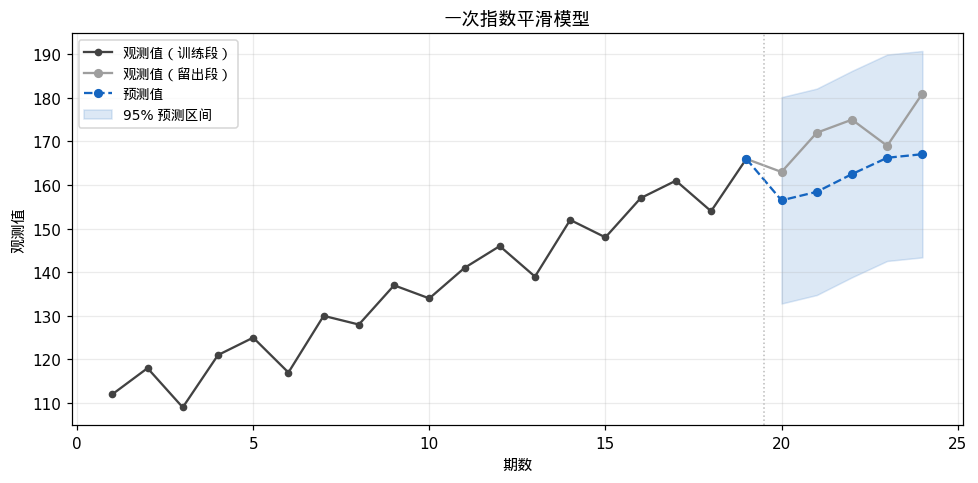

In [6]:
plot_forecast(y, train_n, forecast, se_list, "#1565C0",
              "一次指数平滑模型")

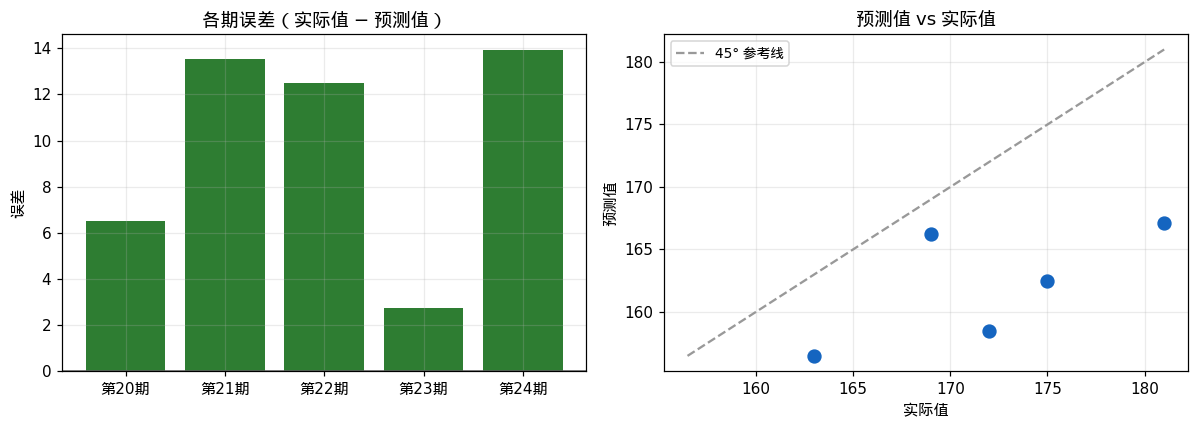

In [7]:
plot_errors(t_index, stats["误差"], actual, forecast, "#1565C0",
            "一次指数平滑模型")